Earliest Start: {'A': 0, 'B': 3.0, 'C': 3.0, 'D': 7.0, 'E': 8.0, 'F': 14.0}
Earliest Finish: {'A': 3.0, 'B': 7.0, 'C': 8.0, 'D': 9.0, 'E': 14.0, 'F': 18.0}
Latest Start: {'F': 14.0, 'E': 8.0, 'D': 12.0, 'C': 3.0, 'B': 8.0, 'A': 0.0}
Latest Finish: {'A': 3.0, 'B': 12.0, 'C': 8.0, 'D': 14.0, 'E': 14.0, 'F': 18.0}
Critical Path: ['A', 'C', 'E', 'F']
Project Duration: 18.0
Project Std Dev: 1.699673171197595


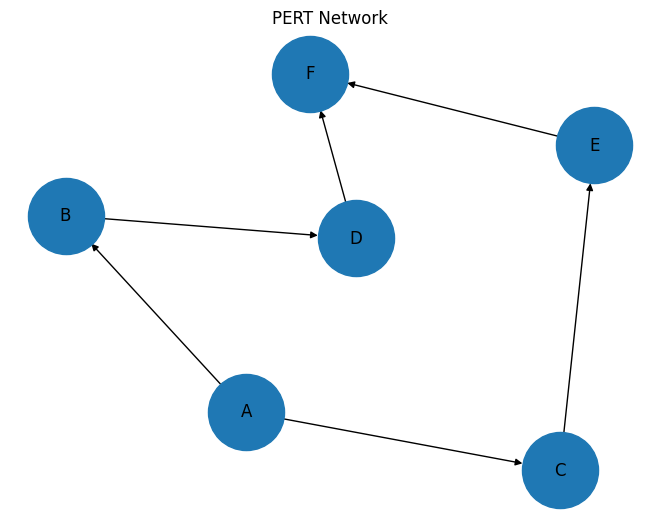

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Define tasks
tasks = {
    'A': {'o': 1, 'm': 3, 'p': 5, 'dependencies': []},
    'B': {'o': 2, 'm': 4, 'p': 6, 'dependencies': ['A']},
    'C': {'o': 2, 'm': 5, 'p': 8, 'dependencies': ['A']},
    'D': {'o': 1, 'm': 2, 'p': 3, 'dependencies': ['B']},
    'E': {'o': 3, 'm': 6, 'p': 9, 'dependencies': ['C']},
    'F': {'o': 2, 'm': 4, 'p': 6, 'dependencies': ['D', 'E']}
}

# -------------------------------
# Compute expected time & variance
for task, data in tasks.items():
    data['te'] = (data['o'] + 4*data['m'] + data['p']) / 6
    data['var'] = ((data['p'] - data['o']) / 6) ** 2

# -------------------------------
# Create graph
G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['te'], variance=data['var'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

# -------------------------------
# Topological order
topo = list(nx.topological_sort(G))

# -------------------------------
# Forward pass
ES = {t: 0 for t in topo}
EF = {}

for t in topo:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for succ in G.successors(t):
        ES[succ] = max(ES[succ], EF[t])

# -------------------------------
# Backward pass
project_duration = max(EF.values())
LF = {t: project_duration for t in topo}
LS = {}

for t in reversed(topo):
    LS[t] = LF[t] - G.nodes[t]['duration']
    for pred in G.predecessors(t):
        LF[pred] = min(LF[pred], LS[t])

# -------------------------------
# Critical path
critical_path = [t for t in topo if abs(ES[t] - LS[t]) < 1e-6]

# -------------------------------
# Project variance & std deviation
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std = np.sqrt(project_variance)

# -------------------------------
# Output
print("Earliest Start:", ES)
print("Earliest Finish:", EF)
print("Latest Start:", LS)
print("Latest Finish:", LF)
print("Critical Path:", critical_path)
print("Project Duration:", project_duration)
print("Project Std Dev:", project_std)

# -------------------------------
# Plot graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000)
plt.title("PERT Network")
plt.show()